# LING 498 Hackathon — Prompt 9

## Phoneme token frequencies (CMUdict)

**Category:** Phonetics

**Question:** Do phoneme tokens (ARPAbet) show Zipf-like frequencies across the lexicon?

- **Data:** NLTK CMUdict: `cmudict.entries()`
- **Items to Count:** Phones with stress stripped: `re.sub(r"\\d","", phone)`

**Steps**
- Iterate pronunciations; normalize phones by removing digits.
- Count all phone tokens; run Zipf report/plot.
- Interpret: why do some phones dominate (inventory, vowel/consonant balance, lexicon bias)?
- Optional: compare consonants-only vs vowels-only distributions.

**Deliverable:** Top-15 phones + one explanation of a surprise + one methodological caveat.

In [16]:
import re
from nltk.corpus import cmudict
from nltk import FreqDist

In [17]:
# Helper functions
def zipf_prep(items, min_count=1):
    fd = FreqDist(items)
    # drop ultra-rare if desired
    items2 = [(k,v) for k,v in fd.items() if v >= min_count]
    items2.sort(key=lambda kv: kv[1], reverse=True)
    return items2  # list of (item, count) sorted

def zipf_quick_report(items, title="", topn=15):
    ranked = zipf_prep(items)
    print(f"\n=== {title} ===")
    print(f"Phoneme Types: {len(ranked)} | Phonemes: {sum(c for _,c in ranked)}")
    print("Top phonemes:")
    for i,(k,v) in enumerate(ranked[:topn], start=1):
        print(f"{i:>2}. {str(k)[:40]:<40} {v}")
    # simple “Zipf-ness” sanity check (no regression): f1 ~ 2*f2 ~ 3*f3?
    if len(ranked) >= 5:
        f1,f2,f3,f4,f5 = [ranked[i][1] for i in range(5)]
        print("\nHeuristic ratios (closer to 1 is more Zipf-like):")
        print(" f1/(2*f2) =", round(f1/(2*f2), 3))
        print(" f1/(3*f3) =", round(f1/(3*f3), 3))
        print(" f1/(4*f4) =", round(f1/(4*f4), 3))
        print(" f1/(5*f5) =", round(f1/(5*f5), 3))
    return ranked

# Optional plotting cell : log Zipf plot
def zipf_plot(ranked, n=1000, title="Zipf Plot"):
    import matplotlib.pyplot as plt
    number_to_plot = min(n, len(ranked))
    ranks = list(range(1, number_to_plot + 1))
    frequencies = []
    for i in ranks:
        frequencies.append(ranked[i - 1][1])
    plt.figure(figsize=(7, 5))
    plt.loglog(ranks, frequencies, marker="o", linestyle="-", markersize=4)
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title(title)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
    
# regular-scale plot 
def zipf_plot_2(ranked, n=30, title="Phoneme Frequency by Rank"):
    import matplotlib.pyplot as plt
    number_to_plot = min(n, len(ranked))
    ranks = list(range(1, number_to_plot + 1))
    frequencies = []
    for i in ranks:
        frequencies.append(ranked[i - 1][1])
    plt.figure(figsize=(8, 5))
    plt.plot(ranks, frequencies, marker="o")
    plt.xlabel("Rank (1 = most common phoneme)")
    plt.ylabel("Frequency (token count)")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

In [18]:
# Load CMUdict entries
entries = cmudict.entries()
print("Number of entries:", len(entries))

Number of entries: 133737


In [19]:
# Remove stress digits from phones (AH0 -> AH)
def normalize_phone(phone: str) -> str:
    return re.sub(r"\d", "", phone)

# List of phoneme tokens across the lexicon
phones = []
for word, pron in entries:
    phones.extend(normalize_phone(p) for p in pron)


=== CMUdict phoneme token frequencies ===
Phoneme Types: 39 | Phonemes: 853918
Top phonemes:
 1. AH                                       71410
 2. N                                        60564
 3. S                                        50427
 4. IH                                       50093
 5. L                                        49479
 6. T                                        48549
 7. R                                        46046
 8. K                                        42502
 9. IY                                       34504
10. D                                        32389
11. M                                        29347
12. ER                                       29027
13. Z                                        27842
14. EH                                       27398
15. AA                                       24546

Heuristic ratios (closer to 1 is more Zipf-like):
 f1/(2*f2) = 0.59
 f1/(3*f3) = 0.472
 f1/(4*f4) = 0.356
 f1/(5*f5) = 0.289


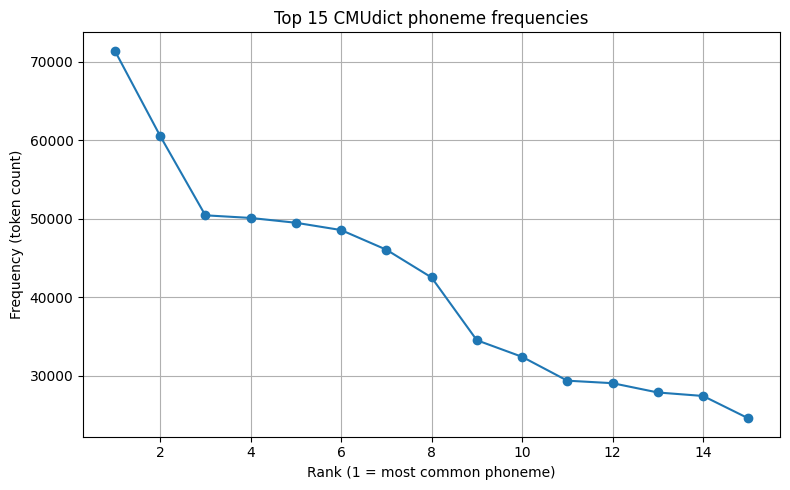

In [22]:
ranked = zipf_quick_report(phones, title="CMUdict phoneme token frequencies")
# zipf_plot(ranked,title="Top 15 CMUdict phoneme frequencies")
zipf_plot_2(ranked,n=15,title="Top 15 CMUdict phoneme frequencies")

### Interpretation

The phoneme distribution follows a Zipf-like pattern, with a small number of phonemes occurring much more frequently than the rest. The most frequent phoneme is `AH`, followed by consonants such as `N`, and `S`, showing that both vowels and consonants contribute heavily to the English lexicon.

**A surprising result**

One surprising result is that `AH` is the most frequent phoneme by a clear margin. This likely happens because `AH` is used for both the stressed vowel /ʌ/ and the unstressed schwa-like vowel /ə/ in CMUdict, so stripping the stress digits merges `AH0`, `AH1`, and `AH2` into one category.

**Methodological caveat**

CMUdict is a pronunciation dictionary, not a corpus of real speech. Each listed pronunciation contributes to the count regardless of how common the word is in everyday language, so these frequencies describe the dictionary’s entries rather than actual spoken phoneme frequencies.